# MLP DESIGN

# PyTorch Project Workflow Pipeline

```mermaid
graph TD
    A[1. Imports] --> B[2. Dataset Downloads]
    B --> C[3. Data Loaders]
    C --> D[4. Class Definition]
    D --> E[5. Object Initialization]
    E --> F[6. To Device Allocation]
    F --> G[7. Optimizer / Loss Setup]
    G --> H[8. Training Loop]
    H --> I[9. Validation Loop]
    I --> J[10. Model Saving]
    J --> K[11. Model Loading]
    K --> L[12. Testing / Inference]
```

---

### 1. Imports
* Load core `torch` library.
* Include structural `nn` module layers.
* Load `optim` weight optimization engines.
* Import `DataLoader` utilities for processing.

### 2. Dataset Downloads
* Source raw training data arrays.
* Fetch validation benchmarking target files.
* Inject standardized feature normalization filters.
* Cache assets locally on disk.

### 3. Data Loaders
* Group data samples into batches.
* Shuffle items to prevent bias.
* Drop incomplete uneven trailing batches.
* Enable multi-threaded memory loading acceleration.

### 4. Class Definition
* Inherit from structural `nn.Module` base.
* Declare layers inside initialization blocks.
* Define input feature mapping size.
* Structure explicit forward mathematical execution.

### 5. Object Initialization
* Instantiate class structures to memory.
* Set unique model dimension hyper-parameters.
* Pass designated hidden layer counts.
* Create trainable weight parameter dictionaries.

### 6. To Device Allocation
* Probe hardware for accelerator availability.
* Target Apple Silicon **MPS** engines.
* Target Nvidia **CUDA** processing cores.
* Cast model state weight weights.

### 7. Optimizer / Loss Setup
* Select error scoring math criteria.
* Instantiate weight decay optimization backends.
* Set master tracking learning rates.
* Bind parameters to optimization schedules.

### 8. Training Loop
* Enable explicit stateful `.train()` rules.
* Zero-out previous step residual gradients.
* Execute fast forward prediction steps.
* Backpropagate errors through historical graphs.

### 9. Validation Loop
* Enforce frozen stateful `.eval()` behaviors.
* Wrap code blocks with `.no_grad()`.
* Track generalization trends over test-sets.
* Check performance changes to prevent overfitting.

### 10. Model Saving
* Access parameters using `.state_dict()` utilities.
* Serialize learning states to files.
* Use standard `.pth` file extensions.
* Export standalone decoupled weight files.

### 11. Model Loading
* Rebuild model class design blueprints.
* Map raw weights back to hardware.
* Inject state configurations using `.load_state_dict()`.
* Verify parameters match underlying architectures.

### 12. Testing / Inference
* Process isolated single-sample production targets.
* Add artificial batch dimensions via `.unsqueeze()`.
* Compute raw categorical logit outputs.
* Convert outputs into single index numbers.


## IMPORTS

In [110]:
import torch
from torch import nn, save, load        #neural net module, save, load module imported
from torch.optim import Adam            # adam optimizer 
from torch.utils.data import DataLoader     # dataloader: iteratable data object
from torchvision import datasets            # dataset
from torchvision.transforms import ToTensor     # data -> Tensor
from tqdm import tqdm       # tqdm for measuring for loops

## DATASETS

In [88]:
train_data=datasets.FashionMNIST(root="./data", download=True, train=True, transform=ToTensor())
test_data=datasets.FashionMNIST(root="./data", download=True, train=False, transform=ToTensor())
# downloads FASHION_MNIST and transforms the image to tensors, for training data set train= true
# train = true makes the datasets. realize which one to download: train or test

In [89]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [90]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()

## DATALOADER

In [91]:
train= DataLoader(train_data, batch_size=32)
test= DataLoader(test_data, batch_size=32)

In [92]:
train

In [93]:
test

In [94]:
data_iter=iter(train)
feature, label =next(data_iter)

In [95]:
feature

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

In [96]:
type(feature)

torch.Tensor

In [97]:
feature.shape

torch.Size([32, 1, 28, 28])

## CLASS

In [98]:
class MLP(nn.Module):
    def __init__(self):# initializer
        super().__init__()# inheritence
        self.model=nn.Sequential(       #model is the pipeline
            nn.Flatten(),   # converts 2d image array to 1d
            nn.Linear(28*28,256),
            nn.Linear(256,128),
            nn.Linear(128,32),
            nn.Linear(32,10),
        )
    def forward(self,x):
        return self.model(x)

## OBJECT


In [99]:
model=MLP().to('mps')

## OPTIM AND LOSS

In [100]:
optimizer=Adam(model.parameters(), lr=1e-3)
loss=nn.CrossEntropyLoss()

In [101]:
type(loss)

torch.nn.modules.loss.CrossEntropyLoss

In [102]:
dir(loss)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__constants__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules',
 '_named_members',
 '_non_per

## TRAINING LOOP

In [103]:
epochs=10

loss is a single element tensor<br><br>
In PyTorch, .item() is a method used to extract a standard Python number (e.g., a standard float or int) from a tensor that contains exactly one element. It is most commonly used for logging training metrics like loss or accuracy without keeping the data attached to the computational graph.

In [104]:
dir(model)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules',
 '_named_members',
 '_non_persistent_buffers_se

In [105]:
next(model.parameters()).device

device(type='mps', index=0)

In [106]:
for epoch in tqdm(range(epochs)):
    for batch in train:
        x,y = batch
        x=x.to('mps')
        y=y.to('mps')
        y_hat=model.forward(x)
        L= loss(y_hat,y)    #outputs, targets
        optimizer.zero_grad()   # clear the old grads instead of adding them up in the computation graph
        L.backward()    # calculate new grads
        optimizer.step()    # grad descent
    print(f"LOSS for epoch : {epoch} : {L.item()}")

 10%|█         | 1/10 [00:07<01:08,  7.64s/it]

LOSS for epoch : 0 : 0.5981941223144531


 20%|██        | 2/10 [00:15<01:00,  7.59s/it]

LOSS for epoch : 1 : 0.59794020652771


 30%|███       | 3/10 [00:22<00:53,  7.58s/it]

...

LOSS for epoch : 7 : 0.4953552484512329


 90%|█████████ | 9/10 [01:07<00:07,  7.32s/it]

LOSS for epoch : 8 : 0.4843904376029968


100%|██████████| 10/10 [01:14<00:00,  7.43s/it]

LOSS for epoch : 9 : 0.47039416432380676


## MODEL SAVING

In [107]:
with open('mlp.pt', 'wb') as f:
    save(model, f)

## MODEL LOADING

In [113]:
mlp=torch.load('mlp.pt',weights_only=False)

## MODEL SET TO EVAL MODE + TESTING

In [116]:
mlp.eval()

MLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): Linear(in_features=128, out_features=32, bias=True)
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
)

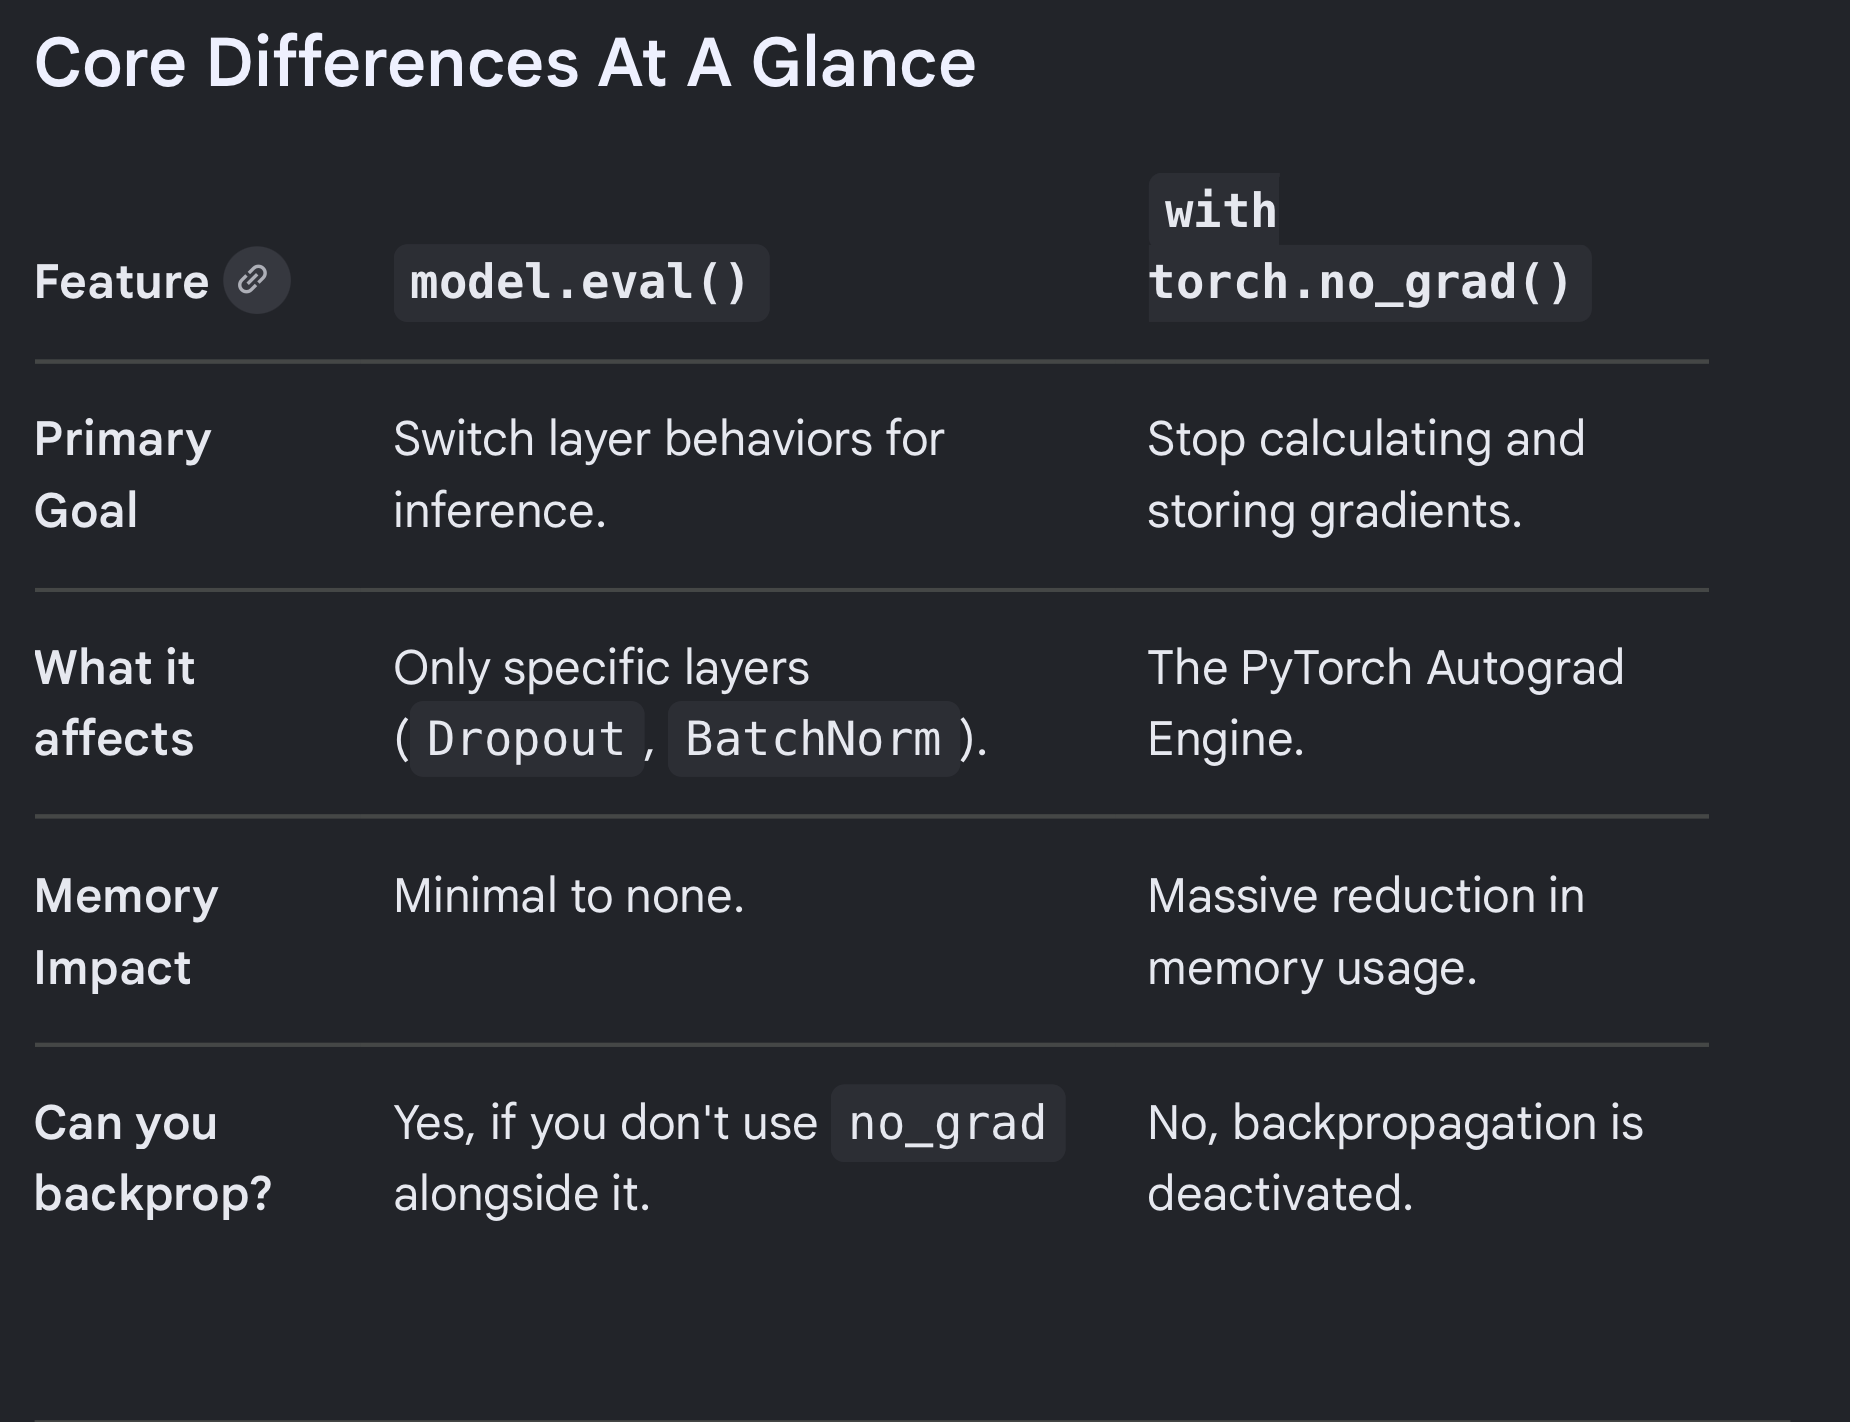

## TESTING


In [120]:
with torch.no_grad():
    total_loss=0
    for batch in test:
        x,y= batch
        x=x.to('mps')
        y=y.to('mps')
        pred=mlp.forward(x)
        L=loss(pred, y)
        total_loss+=L.item()
    print(f"LOSS: {total_loss/len(test)}")      # loss per batch

LOSS: 0.49743655147834326
